In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt

### Setup Dataset

In [39]:
n = 1000
clazz = 5

In [40]:
X = np.zeros((n, 2))
y = np.random.randint(0, clazz, n)

In [41]:
x_center_location = [-5, -1, 0, 3, 5]
x_scale = [1, 2, 2, 1, 2]
y_center_location = [-4, 1, -3, 5, 8]
y_scale = [2, 1, 1, 1, 1]

In [42]:
for i in range(n):
    label = y[i]
    X[i, 0] = np.random.normal(loc=x_center_location[label], scale=x_scale[label])
    X[i, 1] = np.random.normal(loc=y_center_location[label], scale=y_scale[label])

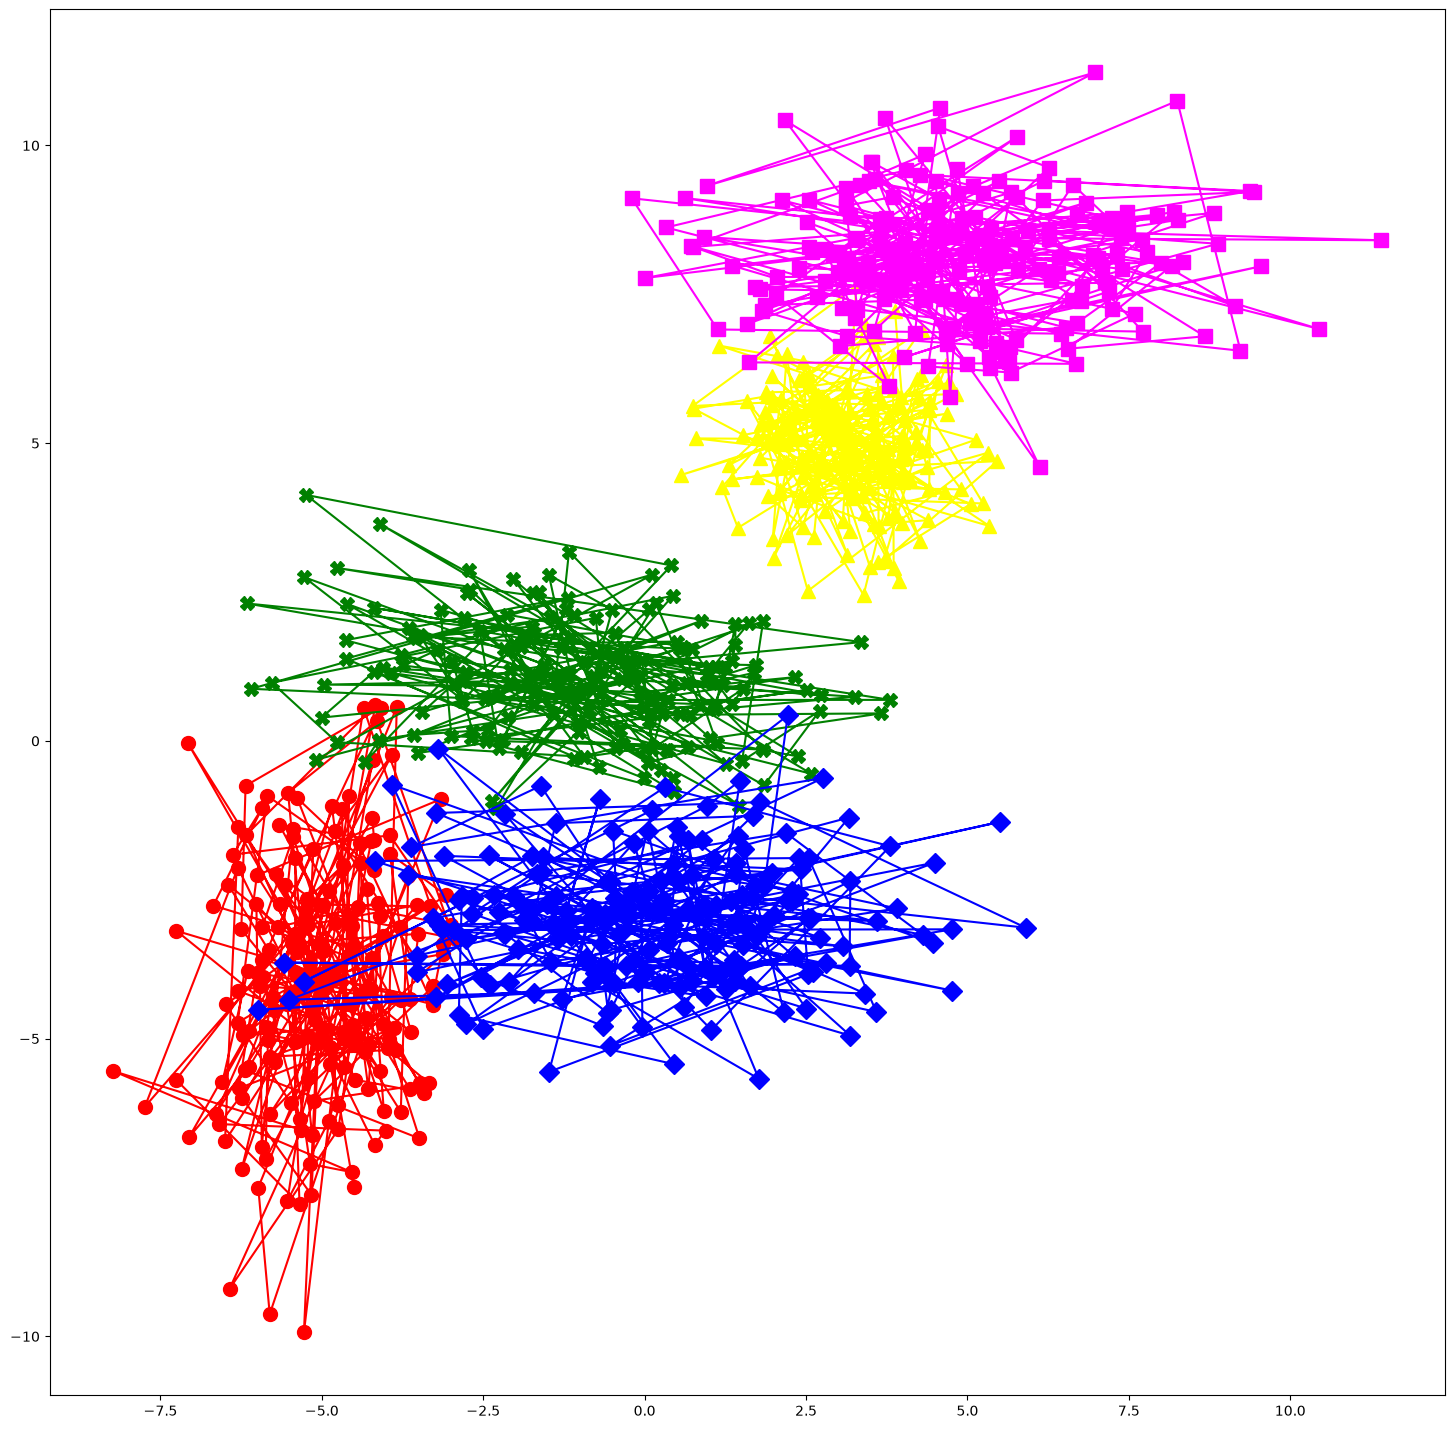

In [43]:
color=["red", "green", "blue", "yellow", "magenta"]
markers = ["o", "X", "D", "^", "s"]
plt.figure(figsize=(18, 18))
for i in range(0, clazz):
    is_class = (y==i)
    plt.plot(X[is_class, 0], X[is_class, 1], color=color[i], marker=markers[i], markersize=10)
plt.show()

### Compute Euclidean Distance

In [44]:
D = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        D[i, j] = np.sqrt((X[i, 0] - X[j, 0])**2 + (X[i, 1] - X[j, 1])**2)

### Compute The Coordination of Decision Boundary

In [49]:
h=0.05

xx0 = np.arange(min(X[:, 0]), max(X[:, 0]), h)
xx1 = np.arange(min(X[:, 1]), max(X[:, 1]), h)

plt_decision_boundary = np.zeros((len(xx0), len(xx1), n))
for i in range(len(xx0)):
    for j in range(len(xx1)):
        plt_decision_boundary[i, j, :] = np.sqrt(
            (xx0[i] - X[:, 0])**2 + (xx1[j] - X[:, 1])**2)

### K-Nearest Neighbor

In [60]:
plot_color=["#FF7777","#77FF77","#7777FF","#FFFF77","#FF77FF"]
k = 5
y_pred = np.zeros(n)

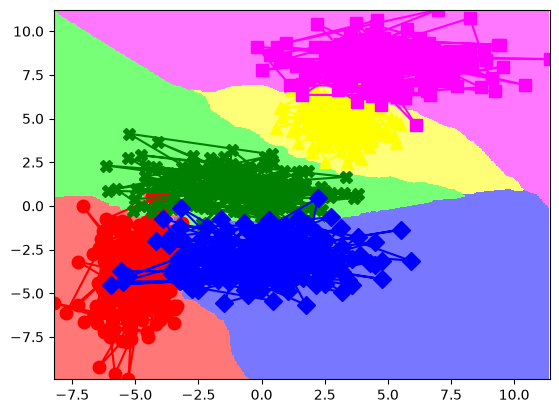

<Figure size 1800x1800 with 0 Axes>

In [64]:
fig = plt.figure()
ax = fig.add_subplot(111, xlim=(min(X[:,0]),max(X[:,0])), ylim=(min(X[:,1]),max(X[:,1])))
plt.figure(figsize=(18,18))

for i in range(n):
    k_indicates = np.argsort(D[i, :])[:k]
    y_candidates = y[k_indicates]
    y_pred[i] = np.bincount(y_candidates).argmax()

for i in range(len(xx0)):
    for j in range(len(xx1)):
        plot_ed_sort_index = np.argsort(plt_decision_boundary[i, j, :])
        candidate = plot_ed_sort_index[0:k]
        class_index=int(np.argmax(np.bincount(y[candidate])))
        polygon = plt.Polygon([[xx0[i]+h/2,xx1[j]+h/2],[xx0[i]+h/2,xx1[j]-h/2],[xx0[i]-h/2,xx1[j]-h/2],
                                   [xx0[i]-h/2,xx1[j]+h/2],[xx0[i]+h/2,xx1[j]+h/2]],
                                  fc=plot_color[class_index],alpha=1)
        ax.add_patch(polygon)

for i in range(clazz):
    is_class = (y==i)
    ax.plot(X[is_class, 0], X[is_class, 1], color=color[i], marker=markers[i], markersize=9)

plt.show()